### Import all the necessary libraries

In [54]:
import pandas as pd
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from greedy_auto_time_start_1 import Point, Route

### Import of functions

In [55]:
import greedy_auto_time_start_1 as auto_alg
import greedy_time_simulate_1 as sim_alg
from build_matrices import build_matrices
from k_medoids_2 import find_optimal_n_clusters_kmedoids

In [56]:
OSM_URL = "https://router.project-osrm.org"
OSM_MODE = "driving"
BLOCK_SIZE = 25
CREW_MEMBERS = 3
MAX_WORK_HOURS = 12

### Import the data

In [57]:
depots = pd.read_csv('synthetic_data_kyiv_varash/general.csv')

In [58]:
kyiv = depots[depots['city_name'] == 'Kyiv'].iloc[0]
kyiv_depot = Point("DEPOT", kyiv['depot_lan'], kyiv['depot_lot'], "DEPOT")
varash = depots[depots['city_name'] == 'Varash'].iloc[0]
varash_depot = Point("DEPOT", varash['depot_lan'], varash['depot_lot'], "DEPOT")

In [59]:
depots_simple = pd.read_csv('synthetic_data_ternopil_dubno/general.csv')

In [60]:
ternopil = depots_simple[depots_simple['city_name'] == 'Ternopil'].iloc[0]
ternopil_depot = Point("DEPOT", ternopil['depot_lan'], ternopil['depot_lot'], "DEPOT")
dubno = depots_simple[depots_simple['city_name'] == 'Dubno'].iloc[0]
dubno_depot = Point("DEPOT", dubno['depot_lan'], dubno['depot_lot'], "DEPOT")

In [61]:
kyiv_small = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_15.csv')
kyiv_small_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_03.csv')
kyiv_meduim_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_22.csv')
kyiv_meduim_2 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_11.csv')
kyiv_meduim_3 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_05.csv')
kyiv_meduim_4 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_12.csv')
kyiv_meduim_5 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_25.csv')
kyiv_gross_1 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_02.csv')
kyiv_gross_2 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_23.csv')
kyiv_gross_3 = pd.read_csv('synthetic_data_kyiv_varash/kyiv/kyiv_day_19.csv')
varash_small = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_15.csv')
varash_small_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_23.csv')
varash_medium_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_10.csv')
varash_medium_2 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_21.csv')
varash_medium_3 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_09.csv')
varash_medium_4 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_24.csv')
varash_medium_5 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_12.csv')
varash_gross_1 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_06.csv')
varash_gross_2 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_02.csv')
varash_gross_3 = pd.read_csv('synthetic_data_kyiv_varash/varash/varash_day_25.csv')
ternopil_small = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_07.csv')
ternopil_small_1 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_25.csv')
ternopil_medium_1 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_22.csv')
ternopil_medium_2 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_14.csv')
ternopil_medium_3 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_23.csv')
ternopil_medium_4 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_24.csv')
ternopil_medium_5 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_13.csv')
ternopil_groos = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_01.csv')
ternopil_groos_2 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_02.csv')
ternopil_groos_3 = pd.read_csv('synthetic_data_ternopil_dubno/ternopil/ternopil_day_15.csv')
dubno_small = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_01.csv')
dubno_small_1 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_21.csv')
dubno_medium_1 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_22.csv')
dubno_medium_2 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_09.csv')
dubno_medium_3 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_17.csv')
dubno_medium_4 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_16.csv')
dubno_medium_5 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_14.csv')
dubno_gross = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_12.csv')
dubno_gross_2 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_11.csv')
dubno_gross_3 = pd.read_csv('synthetic_data_ternopil_dubno/dubno/dubno_day_07.csv')

In [62]:
def format_points(df):
    '''
    function to convert the data into Point class objects
    '''
    df = df.copy()
    df["point_id"] = df["point_id"].astype(str)
    points = []

    for _, row in df.iterrows():
        tw_start = str(row["tw_start"]).strip() if pd.notna(row["tw_start"]) else None
        tw_end = str(row["tw_end"]).strip() if pd.notna(row["tw_end"]) else None

        point_obj = Point(
            str(row["point_id"]),
            row["lan"],
            row["lot"],
            row["point_type"],
            tw_start,
            tw_end
        )

        points.append(point_obj)

    return points

In [63]:
kyiv_s_p = format_points(kyiv_small)
kyiv_s_1_p = format_points(kyiv_small_1)
kyiv_m_1_p = format_points(kyiv_meduim_1)
kyiv_m_2_p = format_points(kyiv_meduim_2)
kyiv_m_3_p = format_points(kyiv_meduim_3)
kyiv_m_4_p = format_points(kyiv_meduim_4)
kyiv_m_5_p = format_points(kyiv_meduim_5)
kyiv_g_1_p = format_points(kyiv_gross_1)
kyiv_g_2_p = format_points(kyiv_gross_2)
kyiv_g_3_p = format_points(kyiv_gross_3)
varash_s_p = format_points(varash_small)
varash_s_1_p = format_points(varash_small_1)
varash_m_1_p = format_points(varash_medium_1)
varash_m_2_p = format_points(varash_medium_2)
varash_m_3_p = format_points(varash_medium_3)
varash_m_4_p = format_points(varash_medium_4)
varash_m_5_p = format_points(varash_medium_5)
varash_g_1_p = format_points(varash_gross_1)
varash_g_2_p = format_points(varash_gross_2)
varash_g_3_p = format_points(varash_gross_3)
ternopil_s_p = format_points(ternopil_small)
ternopil_s_1_p = format_points(ternopil_small_1)
ternopil_m_1_p = format_points(ternopil_medium_1)
ternopil_m_2_p = format_points(ternopil_medium_2)
ternopil_m_3_p = format_points(ternopil_medium_3)
ternopil_m_4_p = format_points(ternopil_medium_4)
ternopil_m_5_p = format_points(ternopil_medium_5)
ternopil_g_p= format_points(ternopil_groos)
ternopil_g_2_p = format_points(ternopil_groos_2)
ternopil_g_3_p= format_points(ternopil_groos_3)
dubno_s_p = format_points(dubno_small)
dubno_s_1_p = format_points(dubno_small_1)
dubno_m_1_p = format_points(dubno_medium_1)
dubno_m_2_p = format_points(dubno_medium_2)
dubno_m_3_p = format_points(dubno_medium_3)
dubno_m_4_p = format_points(dubno_medium_4)
dubno_m_5_p = format_points(dubno_medium_5)
dubno_g_p = format_points(dubno_gross)
dubno_g_2_p = format_points(dubno_gross_2)
dubno_g_3_p = format_points(dubno_gross_3)

In [64]:
def set_params(crew, crew_members, max_hours_work):
    result = dict()
    result['max_crews'] = crew
    result['max_workers'] =  crew*crew_members
    result['workers_per_crew'] =  crew_members
    result['max_route_duration_min'] = max_hours_work * 60
    return result

In [65]:
params_varash = set_params(varash['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_kyiv = set_params(kyiv['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_ternopil = set_params(ternopil['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)
params_dubno = set_params(dubno['fixed_crew'], CREW_MEMBERS, MAX_WORK_HOURS)

In [66]:
cases = [
        {
            "name": "Kyiv_small",
            "depo": kyiv_depot,
            "stops": kyiv_s_p,
            "params": params_kyiv
        },
        {
            "name": "Kyiv_small_1",
            "depo": kyiv_depot,
            "stops": kyiv_s_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_1",
            "depo": kyiv_depot,
            "stops": kyiv_m_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_2",
            "depo": kyiv_depot,
            "stops": kyiv_m_2_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_3",
            "depo": kyiv_depot,
            "stops": kyiv_m_3_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_4",
            "depo": kyiv_depot,
            "stops": kyiv_m_4_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_medium_5",
            "depo": kyiv_depot,
            "stops": kyiv_m_5_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_1",
            "depo": kyiv_depot,
            "stops": kyiv_g_1_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_2",
            "depo": kyiv_depot,
            "stops": kyiv_g_2_p,
            "params": params_kyiv
        },
        {
           "name": "Kyiv_gross_3",
            "depo": kyiv_depot,
            "stops": kyiv_g_3_p,
            "params": params_kyiv
        },
        {
            "name": "Varash_small",
            "depo": varash_depot,
            "stops": varash_s_p,
            "params": params_varash
        },
        {
            "name": "Varash_small_1",
            "depo": varash_depot,
            "stops": varash_s_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_1",
            "depo": varash_depot,
            "stops": varash_m_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_2",
            "depo": varash_depot,
            "stops": varash_m_2_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_3",
            "depo": varash_depot,
            "stops": varash_m_3_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_4",
            "depo": varash_depot,
            "stops": varash_m_4_p,
            "params": params_varash
        },
        {
            "name": "Varash_medium_5",
            "depo": varash_depot,
            "stops": varash_m_5_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_1",
            "depo": varash_depot,
            "stops": varash_g_1_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_2",
            "depo": varash_depot,
            "stops": varash_g_2_p,
            "params": params_varash
        },
        {
            "name": "Varash_gross_3",
            "depo": varash_depot,
            "stops": varash_g_3_p,
            "params": params_varash
        }
]

In [67]:
cases_simple = [
        {
            "name": "ternopil_small",
            "depo": ternopil_depot,
            "stops": ternopil_s_p,
            "params": params_ternopil
        },
        {
            "name": "ternopil_small_1",
            "depo": ternopil_depot,
            "stops": ternopil_s_1_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_1",
            "depo": ternopil_depot,
            "stops": ternopil_m_1_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_2",
            "depo": ternopil_depot,
            "stops": ternopil_m_2_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_3",
            "depo": ternopil_depot,
            "stops": ternopil_m_3_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_4",
            "depo": ternopil_depot,
            "stops": ternopil_m_4_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_medium_5",
            "depo": ternopil_depot,
            "stops": ternopil_m_5_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_1",
            "depo": ternopil_depot,
            "stops": ternopil_g_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_2",
            "depo": ternopil_depot,
            "stops": ternopil_g_2_p,
            "params": params_ternopil
        },
        {
           "name": "ternopil_gross_3",
            "depo": ternopil_depot,
            "stops": ternopil_g_3_p,
            "params": params_ternopil
        },
        {
            "name": "dubno_small",
            "depo": dubno_depot,
            "stops": dubno_s_p,
            "params": params_dubno
        },
        {
            "name": "dubno_small_1",
            "depo": dubno_depot,
            "stops": dubno_s_1_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_1",
            "depo": dubno_depot,
            "stops": dubno_m_1_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_2",
            "depo": dubno_depot,
            "stops": dubno_m_2_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_3",
            "depo": dubno_depot,
            "stops": dubno_m_3_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_4",
            "depo": dubno_depot,
            "stops": dubno_m_4_p,
            "params": params_dubno
        },
        {
            "name": "dubno_medium_5",
            "depo": dubno_depot,
            "stops": dubno_m_5_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_1",
            "depo": dubno_depot,
            "stops": dubno_g_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_2",
            "depo": dubno_depot,
            "stops": dubno_g_2_p,
            "params": params_dubno
        },
        {
            "name": "dubno_gross_3",
            "depo": dubno_depot,
            "stops": dubno_g_3_p,
            "params": params_dubno
        }
]

### Run the clasterization

In [68]:
fixed_seed = 42
best_iter_num = 10

In [69]:
def run_clusterization(cases, function, fixed_seed, iter_num, extra_kwargs=None):
    all_results = []
    
    for case in cases:
        name = case["name"]
        current_cache = f"cache_routes/cache_{name}.json"

        coords = [(case["depo"].lat, case["depo"].lon)] + [
            (s.lat, s.lon) for s in case["stops"]
        ]

        dist_km, time_min = build_matrices(
            coords=coords,
            cache_path=current_cache,
            name=name,
            block_size=25,
            osm_url=OSM_URL,
            osm_mode=OSM_MODE
        )

        build_routes_kwargs = {
            "max_crews": case["params"]["max_crews"],
            "max_workers": case["params"]["max_workers"],
            "workers_per_crew": case["params"]["workers_per_crew"],
            "max_route_duration_min": case["params"]["max_route_duration_min"],
        }

        if extra_kwargs is not None:
            build_routes_kwargs.update(extra_kwargs)

        result = find_optimal_n_clusters_kmedoids(
            day_stops=case["stops"],
            depo=case["depo"],
            dist_km=dist_km,
            time_min=time_min,
            max_crews=case["params"]["max_crews"],
            build_routes_ag=function,
            build_routes_kwargs=build_routes_kwargs,
            random_state=fixed_seed,
            max_iter=iter_num
        )

        case_result = {
            "case_name": name,
            "day_stops": case["stops"],
            "depo": case["depo"],
            "params": case["params"],
            "dist_km": dist_km,
            "time_min": time_min,
            "cluster_result": result,
            "routes": result["routes"],
            "summary": result["summary"],
            "labels": result["labels"],
            "medoid_indices": result["medoid_indices"],
            "cluster_details": result["cluster_details"],
        }

        all_results.append(case_result)

    return all_results

In [70]:
clust_data_original_math = run_clusterization(cases, auto_alg.build_routes, fixed_seed, best_iter_num)
clust_data_original_sim = run_clusterization(cases, sim_alg.build_routes, fixed_seed, best_iter_num, 
        extra_kwargs={
        "start_from": "08:00",
        "start_to": "10:00",
        "step_min": 10,
        "target_duration": 480
    })

In [71]:
clust_data_simple_math = run_clusterization(cases_simple, auto_alg.build_routes, fixed_seed, best_iter_num)
clust_data_simple_sim = run_clusterization(cases_simple, sim_alg.build_routes, fixed_seed, best_iter_num, 
        extra_kwargs={
        "start_from": "08:00",
        "start_to": "10:00",
        "step_min": 10,
        "target_duration": 480
    })

### Test ALNS parameters

In [72]:
from alns_3 import GlobalALNS, InfeasibleError

In [78]:
def run_alns_parameter_testing(
    clustered_cases,
    route_cls,
    max_iterations,
    q_min_q_max,
    seeds,
    initial_temperature=50.0,
    cooling_rate=0.995,
    reaction_factor=0.2,
    segment_length=25,
    score_global_best=5.0,
    score_improved_current=3.0,
    score_accepted_worse=1.0):
    results = []

    for case in clustered_cases:
        case_name = case["case_name"]

        for seed, max_iter, q_pair in product(seeds, max_iterations, q_min_q_max):
            q_min, q_max = q_pair

            alns = GlobalALNS(
                day_stops=case["day_stops"],
                depo=case["depo"],
                dist_km=case["dist_km"],
                time_min=case["time_min"],
                max_route_duration_min=case["params"]["max_route_duration_min"],
                random_state=seed
            )

            destroy_history = []
            repair_history = []

            original_apply_destroy = alns.apply_destroy
            original_apply_repair = alns.apply_repair

            def tracked_apply_destroy(operator_name, solution, q):
                destroy_history.append(operator_name)
                return original_apply_destroy(operator_name, solution, q)

            def tracked_apply_repair(operator_name, partial_solution, removed_points):
                repair_history.append(operator_name)
                return original_apply_repair(operator_name, partial_solution, removed_points)

            alns.apply_destroy = tracked_apply_destroy
            alns.apply_repair = tracked_apply_repair

            try:
                best_routes, best_value = alns.main_alns(
                    initial_routes=case["routes"],
                    route_cls=route_cls,
                    max_iterations=max_iter,
                    q_min=q_min,
                    q_max=q_max,
                    initial_temperature=initial_temperature,
                    cooling_rate=cooling_rate,
                    reaction_factor=reaction_factor,
                    segment_length=segment_length,
                    score_global_best=score_global_best,
                    score_improved_current=score_improved_current,
                    score_accepted_worse=score_accepted_worse
                )

                total_duration, total_distance = best_value

                results.append({
                    "case_name": case_name,
                    "seed": seed,
                    "max_iterations": max_iter,
                    "q_min": q_min,
                    "q_max": q_max,
                    "initial_temperature": initial_temperature,
                    "cooling_rate": cooling_rate,
                    "segment_length": segment_length,
                    "total_duration": total_duration,
                    "total_distance": total_distance,
                    "n_destroy_calls": len(destroy_history),
                    "n_repair_calls": len(repair_history),
                    "random_removal_count": destroy_history.count("random_removal"),
                    "worst_removal_count": destroy_history.count("worst_removal"),
                    "greedy_insertion_count": repair_history.count("greedy_insertion"),
                    "regret_insertion_count": repair_history.count("regret_insertion"),
                    "status": "ok",
                    "best_routes": best_routes
                })

            except InfeasibleError as e:
                results.append({
                    "case_name": case_name,
                    "seed": seed,
                    "max_iterations": max_iter,
                    "q_min": q_min,
                    "q_max": q_max,
                    "initial_temperature": initial_temperature,
                    "cooling_rate": cooling_rate,
                    "segment_length": segment_length,
                    "total_duration": float("inf"),
                    "total_distance": float("inf"),
                    "n_destroy_calls": len(destroy_history),
                    "n_repair_calls": len(repair_history),
                    "random_removal_count": destroy_history.count("random_removal"),
                    "worst_removal_count": destroy_history.count("worst_removal"),
                    "greedy_insertion_count": repair_history.count("greedy_insertion"),
                    "regret_insertion_count": repair_history.count("regret_insertion"),
                    "status": f"infeasible: {str(e)}",
                    "best_routes": None
                })

            finally:
                alns.apply_destroy = original_apply_destroy
                alns.apply_repair = original_apply_repair

    return pd.DataFrame(results)

In [89]:
max_iterations = [300, 500, 700]
q_min_q_max = [(1, 3), (2, 5)]
seeds = [42]

In [90]:
alns_original_math = run_alns_parameter_testing(
    clustered_cases=clust_data_original_math,
    route_cls=Route,
    max_iterations=max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [92]:
alns_original_sim = run_alns_parameter_testing(
    clustered_cases=clust_data_original_sim,
    route_cls=Route,
    max_iterations=max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [93]:
alns_simple_math = run_alns_parameter_testing(
    clustered_cases=clust_data_simple_math,
    route_cls=Route,
    max_iterations=max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [94]:
alns_simple_sim = run_alns_parameter_testing(
    clustered_cases=clust_data_simple_sim,
    route_cls=Route,
    max_iterations=max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [101]:
new_max_iterations = [1000, 2000]

In [102]:
alns_original_math_more = run_alns_parameter_testing(
    clustered_cases=clust_data_original_math,
    route_cls=Route,
    max_iterations=new_max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [103]:
alns_original_sim_more = run_alns_parameter_testing(
    clustered_cases=clust_data_original_sim,
    route_cls=Route,
    max_iterations=new_max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [104]:
alns_sim_math_more = run_alns_parameter_testing(
    clustered_cases=clust_data_simple_math,
    route_cls=Route,
    max_iterations=new_max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [105]:
alns_simple_sim_more = run_alns_parameter_testing(
    clustered_cases=clust_data_simple_sim,
    route_cls=Route,
    max_iterations=new_max_iterations,
    q_min_q_max=q_min_q_max,
    seeds=seeds
)

In [107]:
max_iters_to_test = max_iterations + new_max_iterations
new_seed_to_test = [100]

In [110]:
alns_original_math_more_seeds = run_alns_parameter_testing(
    clustered_cases=clust_data_original_math,
    route_cls=Route,
    max_iterations=max_iters_to_test,
    q_min_q_max=q_min_q_max,
    seeds=new_seed_to_test
)

In [109]:
alns_original_sim_more_seeds = run_alns_parameter_testing(
    clustered_cases=clust_data_original_sim,
    route_cls=Route,
    max_iterations=max_iters_to_test,
    q_min_q_max=q_min_q_max,
    seeds=new_seed_to_test
)

In [108]:
alns_sim_math_more_seeds = run_alns_parameter_testing(
    clustered_cases=clust_data_simple_math,
    route_cls=Route,
    max_iterations=max_iters_to_test,
    q_min_q_max=q_min_q_max,
    seeds=new_seed_to_test
)

In [111]:
alns_sim_sim_more_seeds = run_alns_parameter_testing(
    clustered_cases=clust_data_simple_sim,
    route_cls=Route,
    max_iterations=max_iters_to_test,
    q_min_q_max=q_min_q_max,
    seeds=new_seed_to_test
)

----------

In [116]:
all_alns_df = pd.concat([
    alns_original_math.assign(Method="Math_Start"),
    alns_original_sim.assign(Method="Sim_Start"),
    alns_simple_math.assign(Method="Math_Start"),
    alns_simple_sim.assign(Method="Sim_Start"),
    alns_original_math_more.assign(Method="Math_Start"),
    alns_original_sim_more.assign(Method="Sim_Start"),
    alns_sim_math_more.assign(Method="Math_Start"),
    alns_simple_sim_more.assign(Method="Sim_Start"),
    alns_original_math_more_seeds.assign(Method="Math_Start"),
    alns_original_sim_more_seeds.assign(Method="Sim_Start"),
    alns_sim_math_more_seeds.assign(Method="Math_Start"),
    alns_sim_sim_more_seeds.assign(Method="Sim_Start"),
], ignore_index=True)

In [117]:
all_alns_df

,case_name,seed,max_iterations,q_min,q_max,initial_temperature,cooling_rate,segment_length,total_duration,total_distance,n_destroy_calls,n_repair_calls,random_removal_count,worst_removal_count,greedy_insertion_count,regret_insertion_count,status,best_routes,Method
0,Kyiv_small,42,300,1,3,50.0,0.995,25,9539.490000,2218.4554,300,300,214,86,161,139,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math_Start
1,Kyiv_small,42,300,2,5,50.0,0.995,25,9209.236667,2132.4044,300,300,220,80,150,150,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math_Start
2,Kyiv_small,42,500,1,3,50.0,0.995,25,9312.035000,2145.0120,500,500,365,135,253,247,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math_Start
3,Kyiv_small,42,500,2,5,50.0,0.995,25,9054.090000,2033.0678,500,500,370,130,245,255,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math_Start
4,Kyiv_small,42,700,1,3,50.0,0.995,25,9188.766667,2090.9823,700,700,512,188,339,361,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'KYI...",Math_Start
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,dubno_gross_3,100,700,2,5,50.0,0.995,25,610.813333,112.5571,700,700,397,303,354,346,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Sim_Start
1596,dubno_gross_3,100,1000,1,3,50.0,0.995,25,601.961667,113.9533,1000,1000,560,440,485,515,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Sim_Start
1597,dubno_gross_3,100,1000,2,5,50.0,0.995,25,610.813333,112.5571,1000,1000,556,444,498,502,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Sim_Start
1598,dubno_gross_3,100,2000,1,3,50.0,0.995,25,601.435000,113.3076,2000,2000,1056,944,981,1019,ok,"[Route(crew_id=1, stop_sequence=['DEPOT', 'DUB...",Sim_Start


In [118]:
per_dataset_summary = (
    all_alns_df
    .groupby(
        ["case_name", "Method", "max_iterations", "q_min", "q_max"],
        as_index=False
    )
    .agg(
        mean_duration=("total_duration", "mean"),
        median_duration=("total_duration", "median"),
        std_duration=("total_duration", "std"),
        mean_distance=("total_distance", "mean"),
        median_distance=("total_distance", "median"),
        std_distance=("total_distance", "std"),
        mean_destroy_calls=("n_destroy_calls", "mean"),
        mean_repair_calls=("n_repair_calls", "mean"),
        mean_random_removal=("random_removal_count", "mean"),
        mean_worst_removal=("worst_removal_count", "mean"),
        mean_greedy_insertion=("greedy_insertion_count", "mean"),
        mean_regret_insertion=("regret_insertion_count", "mean"),

    )
)

In [119]:
per_dataset_summary

,case_name,Method,max_iterations,q_min,q_max,mean_duration,median_duration,std_duration,mean_distance,median_distance,std_distance,mean_destroy_calls,mean_repair_calls,mean_random_removal,mean_worst_removal,mean_greedy_insertion,mean_regret_insertion
0,Kyiv_gross_1,Math_Start,300,1,3,12521.126667,12521.126667,101.894087,2883.33350,2883.33350,76.503580,300.0,300.0,218.0,82.0,149.5,150.5
1,Kyiv_gross_1,Math_Start,300,2,5,12172.321667,12172.321667,37.094822,2694.64835,2694.64835,155.949926,300.0,300.0,218.0,82.0,158.0,142.0
2,Kyiv_gross_1,Math_Start,500,1,3,12046.557500,12046.557500,49.076746,2833.64955,2833.64955,117.908854,500.0,500.0,383.0,117.0,257.5,242.5
3,Kyiv_gross_1,Math_Start,500,2,5,11695.915000,11695.915000,34.799082,2586.36850,2586.36850,161.463732,500.0,500.0,378.0,122.0,254.5,245.5
4,Kyiv_gross_1,Math_Start,700,1,3,11848.986667,11848.986667,62.291393,2768.41055,2768.41055,90.364782,700.0,700.0,526.5,173.5,345.5,354.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,ternopil_small_1,Sim_Start,700,2,5,1942.931667,1942.931667,0.000000,309.78485,309.78485,3.635872,700.0,700.0,451.5,248.5,356.5,343.5
796,ternopil_small_1,Sim_Start,1000,1,3,1703.695833,1703.695833,21.681072,366.53700,366.53700,6.482614,1000.0,1000.0,643.5,356.5,479.5,520.5
797,ternopil_small_1,Sim_Start,1000,2,5,1942.931667,1942.931667,0.000000,309.77940,309.77940,3.643580,1000.0,1000.0,620.0,380.0,501.0,499.0
798,ternopil_small_1,Sim_Start,2000,1,3,1688.179167,1688.179167,13.825116,358.90585,358.90585,4.613801,2000.0,2000.0,1252.0,748.0,992.5,1007.5


In [122]:
global_summary = (
    per_dataset_summary
    .groupby(
        ["Method", "max_iterations", "q_min", "q_max"],
        as_index=False
    )
    .agg(
        mean_duration=("mean_duration", "mean"),
        std_duration_across_cases=("mean_duration", "std"),
        mean_distance=("mean_distance", "mean"),
        std_distance_across_cases=("mean_distance", "std"),
        mean_destroy_calls=("mean_destroy_calls", "mean"),
        mean_repair_calls=("mean_repair_calls", "mean"),
        mean_random_removal=("mean_random_removal", "mean"),
        mean_worst_removal=("mean_worst_removal", "mean"),
        mean_greedy_insertion=("mean_greedy_insertion", "mean"),
        mean_regret_insertion=("mean_regret_insertion", "mean"),
    )
)

In [123]:
global_summary

,Method,max_iterations,q_min,q_max,mean_duration,std_duration_across_cases,mean_distance,std_distance_across_cases,mean_destroy_calls,mean_repair_calls,mean_random_removal,mean_worst_removal,mean_greedy_insertion,mean_regret_insertion
0,Math_Start,300,1,3,3855.257417,4167.462266,863.992775,994.365120,300.0,300.0,194.5625,105.4375,145.0625,154.9375
1,Math_Start,300,2,5,3757.455500,3992.498512,836.193626,968.503504,300.0,300.0,189.9875,110.0125,149.0500,150.9500
2,Math_Start,500,1,3,3752.784771,4021.451261,838.640986,969.543251,500.0,500.0,324.4625,175.5375,240.6750,259.3250
3,Math_Start,500,2,5,3636.059646,3822.379539,804.722084,928.070591,500.0,500.0,319.7750,180.2250,248.6500,251.3500
4,Math_Start,700,1,3,3679.971771,3922.144728,817.726803,945.689653,700.0,700.0,447.8750,252.1250,334.6750,365.3250
5,Math_Start,700,2,5,3546.224854,3692.980433,777.811600,884.582266,700.0,700.0,436.9875,263.0125,342.1125,357.8875
6,Math_Start,1000,1,3,3601.440354,3785.562797,791.741380,907.782792,1000.0,1000.0,629.9625,370.0375,479.8875,520.1125
7,Math_Start,1000,2,5,3488.032521,3604.892749,754.297397,851.963485,1000.0,1000.0,614.0500,385.9500,485.1500,514.8500
8,Math_Start,2000,1,3,3463.876063,3559.835849,742.041755,821.387038,2000.0,2000.0,1181.8500,818.1500,973.2375,1026.7625
9,Math_Start,2000,2,5,3445.893437,3530.382335,727.582373,809.146757,2000.0,2000.0,1166.9625,833.0375,978.0875,1021.9125


In [125]:
top_math = (
    global_summary[
        (global_summary["Method"] == "Math_Start")
    ]
    .sort_values(by=["mean_duration", "mean_distance"], ascending=[True, True])
)

In [126]:
top_math

,Method,max_iterations,q_min,q_max,mean_duration,std_duration_across_cases,mean_distance,std_distance_across_cases,mean_destroy_calls,mean_repair_calls,mean_random_removal,mean_worst_removal,mean_greedy_insertion,mean_regret_insertion
9,Math_Start,2000,2,5,3445.893437,3530.382335,727.582373,809.146757,2000.0,2000.0,1166.9625,833.0375,978.0875,1021.9125
8,Math_Start,2000,1,3,3463.876063,3559.835849,742.041755,821.387038,2000.0,2000.0,1181.8500,818.1500,973.2375,1026.7625
7,Math_Start,1000,2,5,3488.032521,3604.892749,754.297397,851.963485,1000.0,1000.0,614.0500,385.9500,485.1500,514.8500
5,Math_Start,700,2,5,3546.224854,3692.980433,777.811600,884.582266,700.0,700.0,436.9875,263.0125,342.1125,357.8875
6,Math_Start,1000,1,3,3601.440354,3785.562797,791.741380,907.782792,1000.0,1000.0,629.9625,370.0375,479.8875,520.1125
3,Math_Start,500,2,5,3636.059646,3822.379539,804.722084,928.070591,500.0,500.0,319.7750,180.2250,248.6500,251.3500
4,Math_Start,700,1,3,3679.971771,3922.144728,817.726803,945.689653,700.0,700.0,447.8750,252.1250,334.6750,365.3250
2,Math_Start,500,1,3,3752.784771,4021.451261,838.640986,969.543251,500.0,500.0,324.4625,175.5375,240.6750,259.3250
1,Math_Start,300,2,5,3757.455500,3992.498512,836.193626,968.503504,300.0,300.0,189.9875,110.0125,149.0500,150.9500
0,Math_Start,300,1,3,3855.257417,4167.462266,863.992775,994.365120,300.0,300.0,194.5625,105.4375,145.0625,154.9375


In [127]:
top_sim = (
    global_summary[
        (global_summary["Method"] == "Sim_Start")
    ]
    .sort_values(by=["mean_duration", "mean_distance"], ascending=[True, True])
)

In [128]:
top_sim

,Method,max_iterations,q_min,q_max,mean_duration,std_duration_across_cases,mean_distance,std_distance_across_cases,mean_destroy_calls,mean_repair_calls,mean_random_removal,mean_worst_removal,mean_greedy_insertion,mean_regret_insertion
18,Sim_Start,2000,1,3,2914.884917,2787.742058,741.588037,822.927124,2000.0,2000.0,1182.5375,817.4625,984.6125,1015.3875
19,Sim_Start,2000,2,5,2917.322333,2799.343608,714.551331,784.682556,2000.0,2000.0,1161.9000,838.1000,977.6625,1022.3375
17,Sim_Start,1000,2,5,2936.650375,2825.493346,731.728399,805.602994,1000.0,1000.0,614.8625,385.1375,482.5500,517.4500
15,Sim_Start,700,2,5,2960.242062,2864.375371,748.196175,829.609039,700.0,700.0,439.1625,260.8375,339.0750,360.9250
16,Sim_Start,1000,1,3,2978.980271,2897.570657,776.803860,879.173904,1000.0,1000.0,630.6625,369.3375,482.7250,517.2750
13,Sim_Start,500,2,5,2997.965063,2927.733483,767.776866,858.401794,500.0,500.0,322.2250,177.7750,246.8250,253.1750
14,Sim_Start,700,1,3,3026.995875,2978.935613,794.782744,904.913834,700.0,700.0,448.7125,251.2875,336.6750,363.3250
11,Sim_Start,300,2,5,3072.678104,3041.210239,795.803139,895.457741,300.0,300.0,191.7000,108.3000,149.0625,150.9375
12,Sim_Start,500,1,3,3075.952875,3055.894816,806.219881,915.687328,500.0,500.0,324.4250,175.5750,242.8125,257.1875
10,Sim_Start,300,1,3,3154.657479,3170.893311,829.565267,939.849115,300.0,300.0,194.6125,105.3875,145.7250,154.2750


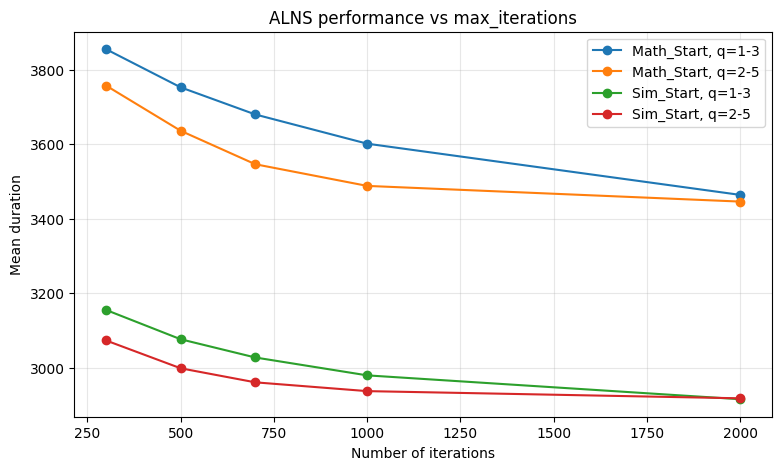

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

for method in global_summary["Method"].unique():
    for (q_min, q_max), part in (
        global_summary[global_summary["Method"] == method]
        .groupby(["q_min", "q_max"])
    ):
        part = part.sort_values("max_iterations")

        plt.plot(
            part["max_iterations"],
            part["mean_duration"],
            marker="o",
            label=f"{method}, q={q_min}-{q_max}"
        )

plt.xlabel("Number of iterations")
plt.ylabel("Mean duration")
plt.title("ALNS performance vs max_iterations")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### The best params

In [ ]:
max_iterations = 1000
q_min_q_max = [(2, 5)]